---
tags: [tutorial]
---

# Reuse Patterns: QKernel Composition and Composite Gates

As circuits grow, you want to avoid copy-pasting gate sequences. Qamomile offers two complementary reuse mechanisms:

1. **Helper QKernel** — call one `@qkernel` from another, like normal
   function composition.
2. **`@composite_gate`** — promote a qkernel to a **named gate**
   with customizable settings that appears as a single box in diagrams.

There is also a third pattern for top-down design:

3. **Opaque oracle** — a callable with no implementation body, used for
   top-down design and resource estimation.
   For example, if you are designing a Grover search algorithm,
   you may know how often an oracle is queried before implementing it.
   An opaque oracle lets you estimate the structure of the algorithm
   without the full oracle implementation.

In [1]:
# Install the latest Qamomile through pip!
# !pip install "qamomile[qiskit,visualization]"

In [2]:
import qamomile.circuit as qmc
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

## Pattern 1: Helper QKernel

Any `@qkernel` function can be called from another `@qkernel`. The transpiler inlines the call — the result is a flat circuit.

In [3]:
@qmc.qkernel
def entangle_once(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_helper(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_once(q[i], q[i + 1])

    return qmc.measure(q)

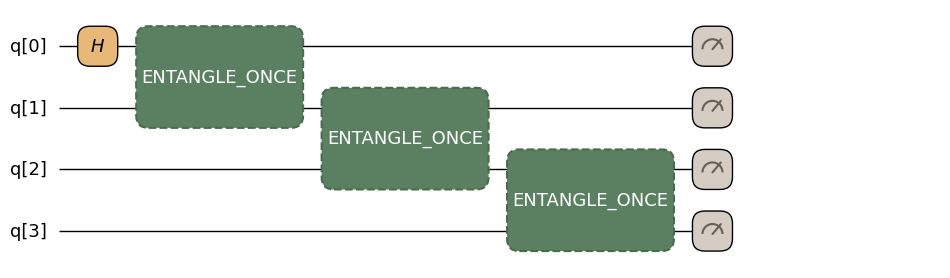

In [4]:
ghz_with_helper.draw(n=4, fold_loops=False)

In [5]:
result = (
    transpiler.transpile(ghz_with_helper, bindings={"n": 4})
    .sample(
        transpiler.executor(),
        shots=128,
    )
    .result()
)
print("GHZ result:", result.results)
assert result.shots == 128
assert sum(count for _, count in result.results) == 128
# 4-qubit GHZ state -> only (0, 0, 0, 0) and (1, 1, 1, 1) outcomes.
assert all(
    outcome in {(0, 0, 0, 0), (1, 1, 1, 1)}
    for outcome, _ in result.results
)

GHZ result: [((1, 1, 1, 1), 60), ((0, 0, 0, 0), 68)]


The helper `entangle_once` keeps the call site readable. In the transpiled circuit, it is inlined — you see individual CX gates, not a sub-block.

In [6]:
qc = transpiler.to_circuit(ghz_with_helper, bindings={"n": 4})
print(qc.draw())

     ┌───┐          ┌─┐              
q_0: ┤ H ├──■───────┤M├──────────────
     └───┘┌─┴─┐     └╥┘     ┌─┐      
q_1: ─────┤ X ├──■───╫──────┤M├──────
          └───┘┌─┴─┐ ║      └╥┘┌─┐   
q_2: ──────────┤ X ├─╫───■───╫─┤M├───
               └───┘ ║ ┌─┴─┐ ║ └╥┘┌─┐
q_3: ────────────────╫─┤ X ├─╫──╫─┤M├
                     ║ └───┘ ║  ║ └╥┘
c: 4/════════════════╩═══════╩══╩══╩═
                     0       1  2  3 


### Passing scalar literals to helpers

When a helper qkernel declares a scalar parameter (`UInt`, `Float`, or `Bit`), you can pass a raw Python literal at the call site — Qamomile auto-promotes `int` to `UInt`, `float` to `Float`, and `bool` to `Bit`. Writing `helper(q, 0, 0.5)` is equivalent to `helper(q, qmc.uint(0), qmc.float_(0.5))`. Use the explicit `qmc.uint` / `qmc.float_` / `qmc.bit` constructors only when you want to name the value or share it across multiple call sites.

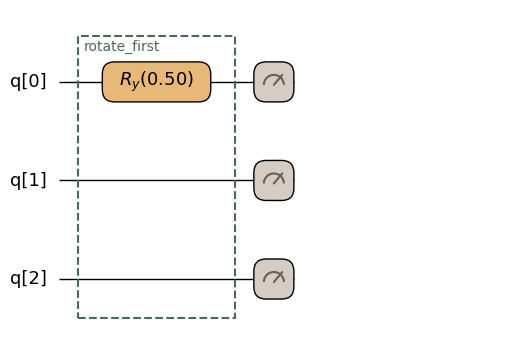

In [7]:
@qmc.qkernel
def rotate_first(
    q: qmc.Vector[qmc.Qubit],
    idx: qmc.UInt,
    angle: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    q[idx] = qmc.ry(q[idx], angle)
    return q


@qmc.qkernel
def helper_with_literals(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    # Raw int / float literals are auto-promoted to ``qmc.UInt`` / ``qmc.Float``
    # at runtime, but the static signature keeps the strict handle types so the
    # kernel contract stays in terms of Qamomile handles. The ignore below
    # acknowledges the deliberate gap between the static signature and the
    # runtime literal-acceptance.
    q = rotate_first(q, 0, 0.5)  # type: ignore[arg-type]
    return qmc.measure(q)


helper_with_literals.draw(n=3, fold_loops=False, inline=True)

## Pattern 2: `@composite_gate`

When you want a reusable block to appear as a **named box** in circuit diagrams, promote it with `@composite_gate`. Also, as a more advanced use case, making it a composite gate allows you to give it custom settings such as giving it multiple ways of implementation.

Stack `@composite_gate(name="...")` on top of `@qkernel`:

In [8]:
@qmc.composite_gate(name="entangle")
@qmc.qkernel
def entangle_link(q0: qmc.Qubit, q1: qmc.Qubit) -> tuple[qmc.Qubit, qmc.Qubit]:
    q0, q1 = qmc.cx(q0, q1)
    return q0, q1


@qmc.qkernel
def ghz_with_composite(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, name="q")
    q[0] = qmc.h(q[0])

    for i in qmc.range(n - 1):
        q[i], q[i + 1] = entangle_link(q[i], q[i + 1])

    return qmc.measure(q)

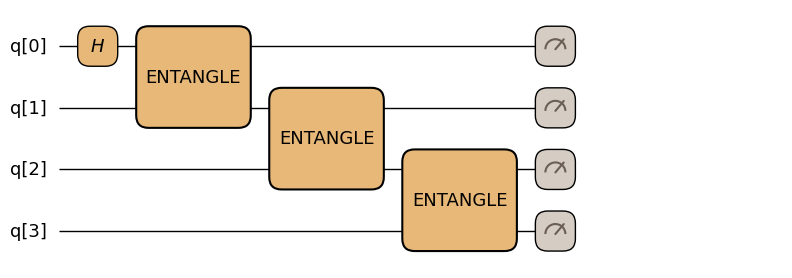

In [9]:
ghz_with_composite.draw(n=4, fold_loops=False)

### When to use which?

| Pattern | Appears in `draw()` | Use when |
|---------|---------------------|------|
| Helper `@qkernel` | Inlined (flat) | Code organization |
| `@composite_gate` | Named box | Domain-level abstraction/advanced settings |

## Pattern 3: Opaque Oracle for Top-Down Design

Sometimes you want to design an algorithm's structure before implementing every sub-component. An **opaque oracle** has no implementation body — just a name, qubit count, and optional resource contract.

This lets you estimate the cost of the overall algorithm while the oracle or sub-routine is still under development.

Construct it with `qmc.Oracle(...)`. During estimation, `UnknownResourcePolicy.OPAQUE_CALL` records each unresolved invocation as an opaque call and query.

In [10]:
oracle_box = qmc.Oracle(
    name="oracle",
    num_qubits=3,
)


@qmc.qkernel
def algorithm_skeleton() -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")
    q = qmc.h(q)

    q[0], q[1], q[2] = oracle_box(q[0], q[1], q[2])
    return q

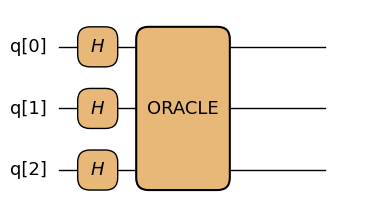

In [11]:
algorithm_skeleton.draw(fold_loops=False)

### Resource Estimation for QKernels that Include Opaque Oracles

`estimate_resources()` can analyze a full qkernel even when oracle internals are unknown. Known scaffold gates are counted directly, and opaque components are tracked through `est.calls.oracle_calls` / `est.calls.oracle_queries`.

In [12]:
est = algorithm_skeleton.estimate_resources(
    unknown_policy=qmc.UnknownResourcePolicy.OPAQUE_CALL,
).simplify()
print("qubits:", est.qubits)
assert est.qubits == 3
print("total gates:", est.gates.total)
# 3 H gates (broadcast over qubit_array(3)); the opaque `oracle_box` is
# counted via calls.oracle_calls, not gates.total.
assert est.gates.total == 3

qubits: 3
total gates: 3


Next, we build a qkernel that mixes ordinary gates with multiple opaque oracles.

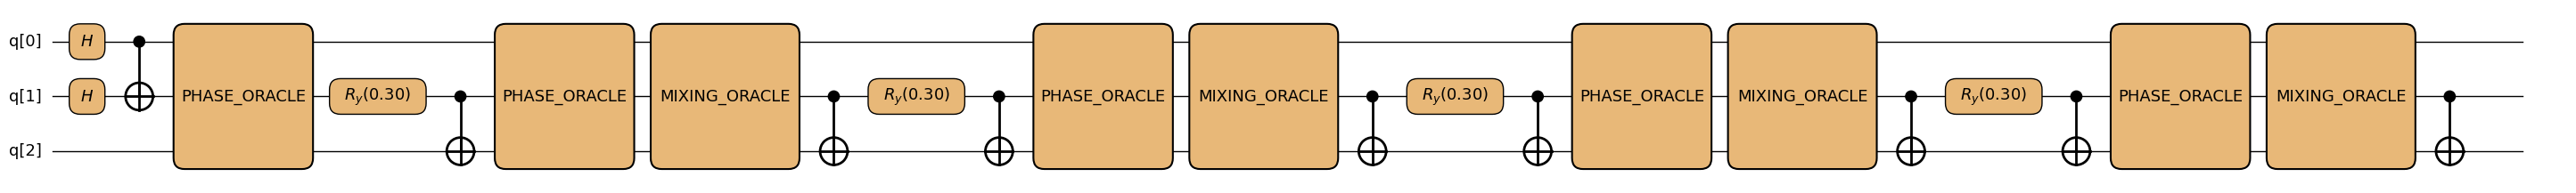

In [13]:
phase_oracle = qmc.Oracle(
    name="phase_oracle",
    num_qubits=3,
)


mixing_oracle = qmc.Oracle(
    name="mixing_oracle",
    num_qubits=3,
)


@qmc.qkernel
def iterative_oracle_skeleton(rounds: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(3, name="q")

    # Known scaffold (non-oracle) gates
    q[0] = qmc.h(q[0])
    q[1] = qmc.h(q[1])
    q[0], q[1] = qmc.cx(q[0], q[1])

    # One oracle call outside the loop
    q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])

    # Each round mixes known gates and unknown oracle blocks
    for i in qmc.range(rounds):
        q[1] = qmc.ry(q[1], 0.3)
        q[1], q[2] = qmc.cx(q[1], q[2])
        q[0], q[1], q[2] = phase_oracle(q[0], q[1], q[2])
        q[0], q[1], q[2] = mixing_oracle(q[0], q[1], q[2])
        q[1], q[2] = qmc.cx(q[1], q[2])

    return q


iterative_oracle_skeleton.draw(rounds=4, fold_loops=False)

In [14]:
oracle_est = iterative_oracle_skeleton.estimate_resources(
    unknown_policy=qmc.UnknownResourcePolicy.OPAQUE_CALL,
).simplify()
print("total gates:", oracle_est.gates.total)
assert str(oracle_est.gates.total) == "3*rounds + 3"
print("two-qubit gates:", oracle_est.gates.two_qubit)
assert str(oracle_est.gates.two_qubit) == "2*rounds + 1"
print("oracle_calls:", oracle_est.calls.oracle_calls)
assert {k: str(v) for k, v in oracle_est.calls.oracle_calls.items()} == {
    "phase_oracle": "rounds + 1",
    "mixing_oracle": "rounds",
}
print("oracle_queries:", oracle_est.calls.oracle_queries)
assert {k: str(v) for k, v in oracle_est.calls.oracle_queries.items()} == {
    "phase_oracle": "rounds + 1",
    "mixing_oracle": "rounds",
}

total gates: 3*rounds + 3
two-qubit gates: 2*rounds + 1
oracle_calls: {'phase_oracle': rounds + 1, 'mixing_oracle': rounds}
oracle_queries: {'phase_oracle': rounds + 1, 'mixing_oracle': rounds}


Substitute a concrete value for `rounds` to get numeric counts:

In [15]:
oracle_est_4 = oracle_est.substitute(rounds=4)
print("oracle_calls (rounds=4):", oracle_est_4.calls.oracle_calls)
assert oracle_est_4.calls.oracle_calls == {"phase_oracle": 5, "mixing_oracle": 4}
print("oracle_queries (rounds=4):", oracle_est_4.calls.oracle_queries)
assert oracle_est_4.calls.oracle_queries == {"phase_oracle": 5, "mixing_oracle": 4}

oracle_calls (rounds=4): {'phase_oracle': 5, 'mixing_oracle': 4}
oracle_queries (rounds=4): {'phase_oracle': 5, 'mixing_oracle': 4}


In this example, resource analysis works without oracle internals: known gates contribute to `total` / `two_qubit`, while unknown oracle blocks are tracked under `calls.oracle_calls` and `calls.oracle_queries`.

This lets you reason about algorithm-level costs (such as qubit count, oracle queries) before committing to a full decomposition.

## Summary

- **Helper `@qkernel`**: call one qkernel from another for code reuse.
  The transpiler inlines the call into a flat circuit.
- **`@composite_gate`**: gives a qkernel a named identity visible in
  diagrams. Stack `@composite_gate` on top of `@qkernel`.
- **Opaque oracle**: `qmc.Oracle` supports top-down design without a full implementation.
- **`est.calls.oracle_calls`**: with `UnknownResourcePolicy.OPAQUE_CALL`, this reports per-oracle call counts, including symbolic counts.

For controlled gates (`qmc.control`), see [Tutorial 04 — Controlled Gates](04_controlled_gates.ipynb).